In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [33]:
df=pd.read_csv('books.csv')
print(df.head())


   NumPages  AvgWordLength  ReadingTimeHours  ComplexityScore    Genre
0       180            4.5               5.2              3.1  Fiction
1       200            4.6               5.8              3.3  Fiction
2       150            4.4               4.5              2.9  Fiction
3       220            4.7               6.1              3.5  Fiction
4       190            4.5               5.4              3.2  Fiction


In [3]:
df.shape

(150, 5)

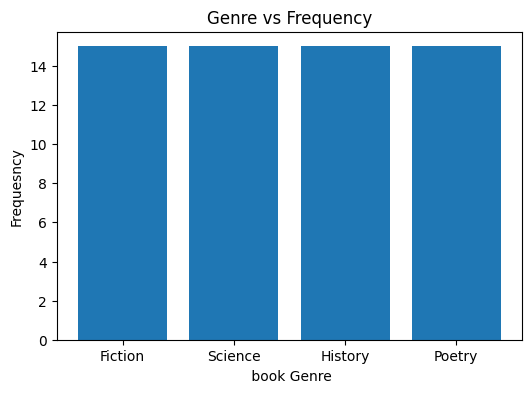

In [21]:
plt.figure(figsize=(6,4))
plt.bar(x=df['Genre'].unique(), height=df['Genre'].value_counts())
plt.xlabel(" book Genre")
plt.ylabel("Frequesncy")
plt.title("Genre vs Frequency")
plt.savefig('plot.png')
plt.show()

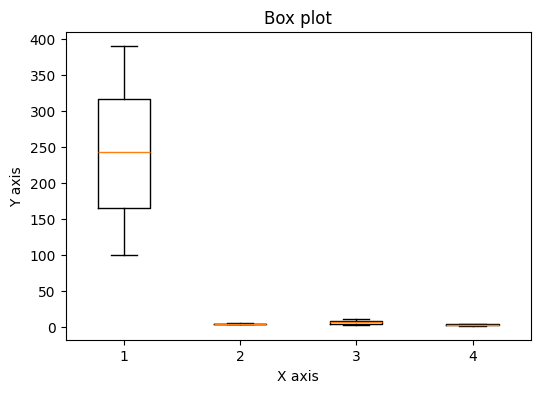

In [22]:
plt.figure(figsize=(6,4))
plt.boxplot(x=df.drop(columns=['Genre']));
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.title("Box plot")
plt.savefig("boxplot.svg",format="svg")
plt.show()


In [23]:
#split into x and y
X= df.drop(columns=['Genre'])
y=df["Genre"]
#to dind the dimenionwe use 
# print(X.shape)
#X.shape

In [34]:
#split into training and testing set 
from sklearn.model_selection import train_test_split
X= df.drop(columns=['Genre'])
y=df['Genre']
print(X.shape)
print(y.shape)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=123)

print(f'length of X_train and y_train ={X_train.shape}{y_train.shape}')
print(f"length of X_test and y_test={X_test.shape}{y_test.shape}")


(60, 4)
(60,)
length of X_train and y_train =(48, 4)(48,)
length of X_test and y_test=(12, 4)(12,)


In [8]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score , classification_report 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [27]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.6666666666666666

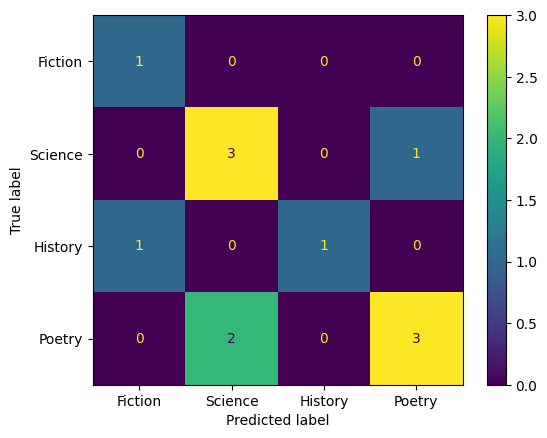

In [28]:
cm =confusion_matrix(y_test,y_pred)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=df['Genre'].unique())

cm_plot.plot()
plt.savefig("cm.png")
plt.show()

In [29]:
X_test

,NumPages,AvgWordLength,ReadingTimeHours,ComplexityScore
24,370,5.3,10.6,4.7
39,305,5.0,8.7,4.1
15,320,5.1,9.2,4.4
31,300,5.0,8.6,4.1
43,325,5.1,9.4,4.3
52,170,4.3,4.6,2.6
18,380,5.3,10.8,4.8
40,295,4.9,8.4,4.0
55,125,4.1,3.4,2.2
13,215,4.6,6.1,3.4


In [30]:
y_test

24    Science
39    History
15    Science
31    History
43    History
52     Poetry
18    Science
40    History
55     Poetry
13    Fiction
26    Science
27    Science
Name: Genre, dtype: object

In [31]:
ans = knn.predict([[370,5.3,10.6,4.7]])
print(ans[0])


Science


c:\Users\victus\anaconda3\envs\sumit\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [32]:
import joblib 
joblib.dump(knn,'knn_model.joblib')
print("SUCCESS")


SUCCESS
